In [116]:
import pandas as pd 
import numpy as np
import sklearn 
import re 

In [117]:
df = pd.read_csv('online_retail_II.csv')

In [118]:
# Remove cancelled Order(Starts with C), remove negetive vlaues in price ans quantity features 
# And Make new feature Total_price 

df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] >= 0) & (df['Price'] >= 0) ]

df['Total_Price'] = df['Quantity'] * df['Price']

In [119]:
# there are 24k+ missing values in customer Id feature so before droping those value,
# we collect some info that might be help full in future

missing_revenue = df[df['Customer ID'].isna()]['Total_Price'].sum()
total_revenue = df['Total_Price'].sum()

print(f"Revanue from missing Customer ID: £ {missing_revenue:,.2f}")
print(f"Total Revanue: £ {total_revenue:,.2f}")
print(f"Revenue loss %: {missing_revenue/total_revenue*100:,.2f}%")

print(df[df['Customer ID'].isna()]['Country'].value_counts().head())

print(df[df['Customer ID'].isna()]['Invoice'].nunique())
    
df = df.dropna(subset=['Customer ID'])

Revanue from missing Customer ID: £ 3,229,165.39
Total Revanue: £ 20,972,594.57
Revenue loss %: 15.40%
Country
United Kingdom    235922
EIRE                1609
Hong Kong            358
Unspecified          231
France               128
Name: count, dtype: int64
4963


# RFM Engineering

In [120]:
# Calculating Recency, Frequency and Monetary from dataset by grouping them by CustomerID 
df = df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],errors='coerce')

rafrance_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate',lambda x:(rafrance_date - x.max()).days),
    Frequency = ('Invoice','nunique'),
    Monetary = ('Total_Price','sum')
).reset_index()

# print(rfm.head())
# print(rfm.describe())

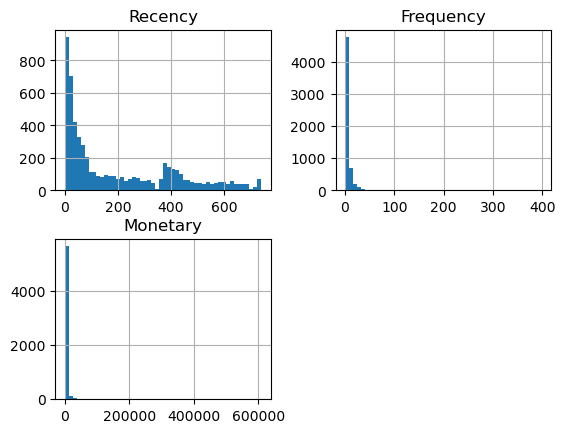

In [121]:
# Check the skewness of the newly created features.

import matplotlib.pyplot as plt 
rfm[['Recency','Frequency','Monetary']].hist(bins=50)
plt.show()

## Handel Skew

In [ ]:
# Performing log transformation for reducing skewness.

rfm["Recency_log"] = np.log1p(rfm['Recency'])
rfm["Frequency_log"] = np.log1p(rfm['Frequency'])
rfm["Monetary_log"] = np.log1p(rfm['Monetary'])

rfm[['Recency_log','Frequency_log','Monetary_log']].hist(bins=50)
plt.show()
rfm['Frequency_log'].skew()

# RFM Scoring

In [128]:
# Calculate individual score as well combime RFM score from RFM values 

rfm['R_score'] = pd.qcut(rfm['Recency_log'],q=5,labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency_log'].rank(method='first'),q=5,labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary_log'], q=5, labels=[1,2,3,4,5])

rfm["RFM_Score"] = rfm['R_score'].astype(str) +rfm['F_score'].astype(str)+rfm['M_score'].astype(str)

def segment_customer(row):
    score = int(row['R_score']) + int(row['F_score']) + int(row['M_score']) 
    if score >= 13:
        return 'Champions'
    elif score >=10:
        return 'Loyal Customers'
    elif score >=7:
        return 'At Risk'
    else :
        return 'Lost'

rfm['sagment'] = rfm.apply(segment_customer,axis=1)
# rfm

# Scaling the values of RFM

In [151]:
# Scaling all features so all features value consider same weight.

from sklearn.preprocessing import StandardScaler

rfm_scaled = rfm[['Recency_log','Frequency_log','Monetary_log']].copy()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_scaled)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled','Frequency_scaled','Monetary_scaled']
)

# Elbow Method 

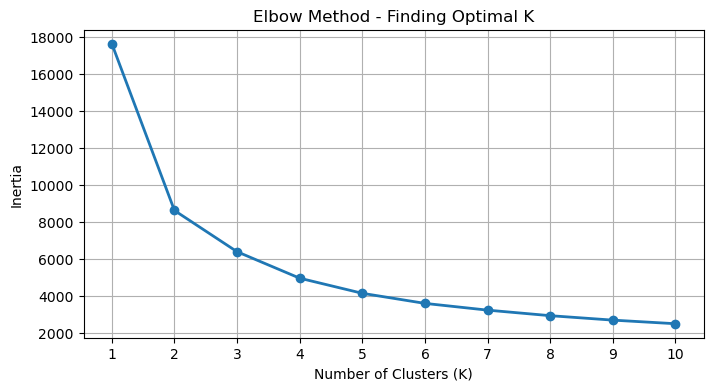

In [154]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1,11)

for k in K_range:
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()


# Silhouette Score

K=2 Silhouette Score: 0.4381
K=3 Silhouette Score: 0.3473
K=4 Silhouette Score: 0.3647
K=5 Silhouette Score: 0.3406
K=6 Silhouette Score: 0.3331
K=7 Silhouette Score: 0.3056
K=8 Silhouette Score: 0.2965
K=9 Silhouette Score: 0.2899
K=10 Silhouette Score: 0.2902


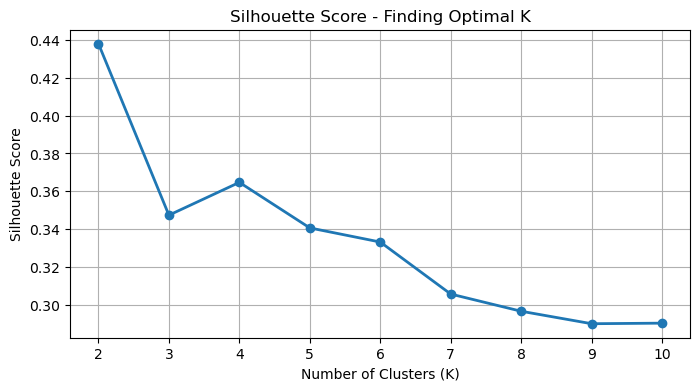

In [155]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled,labels)
    sil_scores.append(score)
    print(f"K={k} Silhouette Score: {score:.4f}")

plt.figure(figsize=(8,4))
plt.plot(range(2,11),sil_scores, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Finding Optimal K')
plt.xticks(range(2,11))
plt.grid(True)
plt.show()